**Disclaimer: Your analysis section should be written in your own words, not generated by AI unless otherwise instructed.**

# Assignment 1: Data Foundations & Predictive Modeling

**Student Name:** [Sebastian Campos]

**Student ID:** [Redacted for public repo]

**Points:** 11

## Assignment Overview

You will work with the <b>Framingham Heart Study</b> dataset, which contains clinical and lifestyle measurements from patients along with whether they went on to develop coronary heart disease within 10 years. This assignment covers the full early pipeline of a machine learning project: cleaning and understanding raw data, engineering and selecting features, and building and evaluating baseline classification models.

## Dataset Information

- File: heart_failure.csv (provided on Canvas; original source: Framingham Heart Study dataset)
- Content: Clinical and lifestyle measurements for ~4,240 patients (sex, age, education, smoking status, cigarettes per day, blood pressure medication, history of stroke/hypertension/diabetes, total cholesterol, systolic/diastolic blood pressure, BMI, heart rate, glucose, and more)
- Target Variable: TenYearCHD (1 = developed coronary heart disease within 10 years, 0 = did not)
- Predictors: all remaining columns

> **Note:** Use your Student ID as the random seed everywhere a seed is required, so your results are reproducible and distinguishable from a classmate's.

## Import Required Libraries

Import all necessary libraries for data analysis, visualization, and machine learning.

In [22]:
# Import necessary libraries for data analysis, visualization, and machine learning
# YOUR CODE HERE:
import pandas as pd, numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split , cross_val_score, KFold
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, auc, roc_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC





### Problem 1a: Dataset Overview

**Instructions:**

Load the dataset and get familiar with it before doing anything else.

**Notes:**

Load heart_failure.csv into a pandas DataFrame; show shape, column names, and data types; produce a data dictionary describing what each column represents; identify which columns are numeric, which are categorical, and which (if any) look miscoded.

In [23]:
# TODO: Load the CSV file into a pandas DataFrame
# TODO: Show shape, dtypes, and the first 5 rows
# TODO: Use describe() for numeric columns and value_counts() for categorical columns
# TODO: Write a short data dictionary as a markdown table or printed summary
# YOUR CODE HERE:

# Load the CSV file into a DataFrame

df = pd.read_csv('heart_failure.csv')



# Show the shape (rows, columns)
print("Shape of the dataset")
print(df.shape)

# Show the data types
print("\nData types")
print(df.dtypes)

# Show the first 5 rows and .head() method grabs and displays the very top rows of your dataset
print("\nFirst 5 rows:")
print(df.head(5))

# Summary for numeric columns
numeric_summary = df.describe()
print(numeric_summary)

# Select only object and categorical columns
categorical_cols = ['male', 'education', 'currentSmoker', 'BPMeds',
                     'prevalentStroke', 'prevalentHyp', 'diabetes', 'TenYearCHD']

# Print value counts for each categorical column to see category frequencies
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())

# Data dictionary: short description of what each column represents
data_dictionary = {
    "male": "Sex indicator (1 = male, 0 = female)",
    "age": "Age of the patient in years",
    "education": "Education level, ordinal code (1 = some high school, 2 = high school graduate, 3 = some college, 4 = college graduate)",
    "currentSmoker": "Whether the patient currently smokes (1 = yes, 0 = no)",
    "cigsPerDay": "Average number of cigarettes smoked per day",
    "BPMeds": "Whether the patient is on blood pressure medication (1 = yes, 0 = no)",
    "prevalentStroke": "Whether the patient previously had a stroke (1 = yes, 0 = no)",
    "prevalentHyp": "Whether the patient has hypertension (1 = yes, 0 = no)",
    "diabetes": "Whether the patient has diabetes (1 = yes, 0 = no)",
    "totChol": "Total cholesterol level (mg/dL)",
    "sysBP": "Systolic blood pressure (mmHg)",
    "diaBP": "Diastolic blood pressure (mmHg)",
    "BMI": "Body Mass Index",
    "heartRate": "Heart rate (beats per minute)",
    "glucose": "Glucose level (mg/dL)",
    "TenYearCHD": "Target: 10-year risk of coronary heart disease (1 = yes, 0 = no)",
}

# Print the data dictionary so each column's meaning is documented
print(data_dictionary)








Shape of the dataset
(4240, 16)

Data types
male                 int64
age                  int64
education          float64
currentSmoker        int64
cigsPerDay         float64
BPMeds             float64
prevalentStroke      int64
prevalentHyp         int64
diabetes             int64
totChol            float64
sysBP              float64
diaBP              float64
BMI                float64
heartRate          float64
glucose            float64
TenYearCHD           int64
dtype: object

First 5 rows:
   male  age  education  currentSmoker  cigsPerDay  BPMeds  prevalentStroke  \
0     1   39        4.0              0         0.0     0.0                0   
1     0   46        2.0              0         0.0     0.0                0   
2     1   48        1.0              1        20.0     0.0                0   
3     0   61        3.0              1        30.0     0.0                0   
4     0   46        3.0              1        23.0     0.0                0   

   prevalentHyp  dia

### 📝 Analysis Explanation (1a)

**Instructions:** Summarize what you learned about the dataset's structure. Flag any columns that look miscoded or unusual.

**Your Analysis:** [Write your interpretation here.]

### Problem 1b: Cleaning & Feature Engineering

**Instructions:**

Handle missing or implausible values (several columns — e.g. totChol, BMI, heartRate, glucose, cigsPerDay, BPMeds, education — contain missing values coded as "NA"; also check whether any numeric columns contain physiologically implausible values, such as a BMI or heart rate of 0), encode categorical variables appropriately, and engineer at least two new features from the existing columns (for example, an age-bucket variable, or a ratio between two clinical measurements).

In [24]:
# TODO: Identify and handle missing or implausible values (state your imputation choice and why)
# TODO: Encode categorical variables (one-hot or ordinal, as appropriate)
# TODO: Engineer at least two new features and justify each in a comment
# TODO: Show the cleaned, encoded DataFrame's shape and head()
# YOUR CODE HERE:

# Load dataset and check missing counts
df = pd.read_csv('heart_failure.csv')
print(df.isnull().sum())

# View summary statistics to find implausible ranges
print(df.describe())

df_cleaned = df.dropna(subset=['heartRate'])  # Drop rows with missing heart rate values for simplicity; could also consider imputation

df_cleaned = df_cleaned[df_cleaned['heartRate'] > 0]  # Remove implausible heart rate values (<= 0)

mode_column = ['BPMeds', 'education']    # Columns with missing values to be imputed with mode

for col in mode_column:
    mode_value = df_cleaned[col].mode()[0]  # Get the mode of the column for imputation
    df_cleaned[col] = df_cleaned[col].fillna(mode_value)  # Impute missing values with mode


median_columns = ['cigsPerDay', 'totChol', 'BMI', 'glucose']  # Columns with missing values to be imputed with median

for col in median_columns:
    median_value = df_cleaned[col].median()  # Get the median of the column for imputation
    df_cleaned[col] = df_cleaned[col].fillna(median_value)  # Impute missing values with median


encoder = OneHotEncoder(sparse_output=False)  # Initialize OneHotEncoder to avoid dummy variable trap

encoded_cols = encoder.fit_transform(df_cleaned[['education']])  # Fit and transform the 'education' column

encoded_df = pd.DataFrame(encoded_cols, columns=encoder.get_feature_names_out(['education']), index=df_cleaned.index)  # Turn the encoded array into a DataFrame with proper column names
df_cleaned = pd.concat([df_cleaned.drop(columns=['education']), encoded_df], axis=1)  # Replace raw 'education' with its one-hot encoded columns


def smoking_category(cigs):
    if cigs == 0:
        return 'non-smoker'  # no cigarettes per day - baseline risk
    elif cigs > 0 and cigs <= 10:
        return 'light smoker'  # up to 10/day - lower exposure than heavier smokers
    elif cigs > 10 and cigs <= 20:
        return 'moderate smoker'  # 11-20/day - roughly a pack or less
    else:
        return 'heavy smoker'  # more than 20/day - highest exposure, likely highest added risk



df_cleaned['smoking_category'] = df_cleaned['cigsPerDay'].apply(smoking_category)  # Create a new feature for smoking category

def heartRateSmoker(beatsSmoker):
    if beatsSmoker <= 60:
        return '60 to 72 BPM'
    elif beatsSmoker <= 76:
        return '70 to 76 BPM'
    elif beatsSmoker <= 90:
        return '75 to 82 BPM'
    else:
        return '80+ BPM'

# Categorize each patient's heart rate into ranges
df_cleaned['beatsSmoker'] = df_cleaned['heartRate'].apply(heartRateSmoker)

print(df_cleaned.head())  # Show the first 5 rows of the cleaned and feature-engineered DataFrame
print(df_cleaned.shape)  # Show the shape of the cleaned DataFrame


male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64
              male          age    education  currentSmoker   cigsPerDay  \
count  4240.000000  4240.000000  4135.000000    4240.000000  4211.000000   
mean      0.429245    49.580189     1.979444       0.494104     9.005937   
std       0.495027     8.572942     1.019791       0.500024    11.922462   
min       0.000000    32.000000     1.000000       0.000000     0.000000   
25%       0.000000    42.000000     1.000000       0.000000     0.000000   
50%       0.000000    49.000000     2.000000       0.000000     0.000000   
75%       1.000000    56.000000     3.000000       1.000000    20.000000   
max       1

### 📝 Analysis Explanation (1b)

**Instructions:** Explain your imputation strategy and why you engineered the specific new features you chose. What did you expect each engineered feature to capture?

**Your Analysis:** [Write your interpretation here.]

### Problem 1c: Feature Selection via Regularization

**Instructions:**

Standardize your features, then fit Ridge and Lasso regression (or logistic regression with L1/L2 penalty, since the target is binary) across a range of regularization strengths. Identify which features Lasso drives to zero and which features remain important across both methods.

c:\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1407: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio se

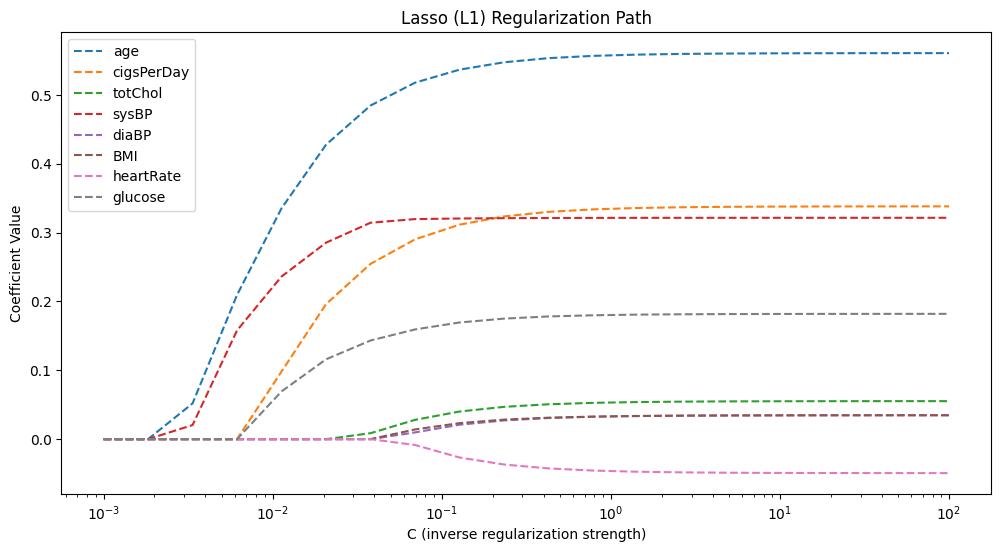

Feature elimination order (Lasso):
age: becomes nonzero at C = 0.0034
cigsPerDay: becomes nonzero at C = 0.0113
totChol: becomes nonzero at C = 0.0379
sysBP: becomes nonzero at C = 0.0034
diaBP: becomes nonzero at C = 0.0695
BMI: becomes nonzero at C = 0.0695
heartRate: becomes nonzero at C = 0.0695
glucose: becomes nonzero at C = 0.0113


In [25]:
# TODO: Standardize numeric features (StandardScaler)
# TODO: Fit L1-penalized (Lasso) and L2-penalized (Ridge) logistic regression across a range of C values
# TODO: Plot how each feature's coefficient changes as the penalty strength changes (a regularization path plot)
# TODO: List the features Lasso eliminates first, and the features that remain important longest
# YOUR CODE HERE:

# Initialize the StandardScaler
scaler = StandardScaler()
standard_df = scaler.fit_transform(df_cleaned[['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']])  # Fit and transform the numeric columns

X = standard_df  # Standardized numeric features used as model input
y = df_cleaned['TenYearCHD']  # Target variable: whether the patient developed heart disease within 10 years

# Range of C values spanning several orders of magnitude - smaller C = stronger penalty
C_values = np.logspace(-3, 2, 20)

lasso_coefs = []  # coefficients from each L1 (Lasso) model
ridge_coefs = []  # coefficients from each L2 (Ridge) model

for C in C_values:
    # Fit L1-penalized (Lasso-style) logistic regression at this C value
    lasso_model = LogisticRegression(penalty='l1', C=C, solver='liblinear', random_state=42)
    lasso_model.fit(X, y)
    lasso_coefs.append(lasso_model.coef_[0])  # Store this model's coefficients for the regularization path plot

    # Fit L2-penalized (Ridge-style) logistic regression at this C value
    ridge_model = LogisticRegression(penalty='l2', C=C, solver='liblinear', random_state=42)
    ridge_model.fit(X, y)
    ridge_coefs.append(ridge_model.coef_[0])  # Store this model's coefficients for the regularization path plot

lasso_coefs = np.array(lasso_coefs)  # Shape: (num C values, num features)
ridge_coefs = np.array(ridge_coefs)  # Shape: (num C values, num features)

# Real column names, in the same order as the coefficient columns, so the plot legend is readable
feature_names = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']

plt.figure(figsize=(12, 6))
# Plot each feature's Lasso (L1) coefficient across all C values
for i in range(lasso_coefs.shape[1]):
    plt.plot(C_values, lasso_coefs[:, i], label=feature_names[i], linestyle='--')

plt.xscale("log")  # C spans several orders of magnitude, so a log scale makes the path readable
plt.xlabel("C (inverse regularization strength)")  # label matches what's actually plotted (C, not alpha)
plt.ylabel("Coefficient Value")  # each line's height shows that feature's coefficient at this C
plt.title("Lasso (L1) Regularization Path")
plt.legend()  # shows which line corresponds to which feature
plt.show()  # renders the plot

# For each feature, find the smallest C at which Lasso first gives it a nonzero coefficient.
# A feature that only turns nonzero at a large C (weak penalty) is one Lasso eliminates
# early/aggressively; a feature that's already nonzero at the smallest C survives the
# strongest penalty and is the most important.
print("Feature elimination order (Lasso):")
for i, name in enumerate(feature_names):
    nonzero_indices = np.where(lasso_coefs[:, i] != 0)[0]  # indices where this feature's coefficient isn't zero
    if len(nonzero_indices) > 0:
        first_c = C_values[nonzero_indices[0]]  # smallest C where the coefficient turned nonzero
        print(f"{name}: becomes nonzero at C = {first_c:.4f}")
    else:
        print(f"{name}: always zero across all tested C values")  # Lasso eliminated it at every C tested


### 📝 Analysis Explanation (1c)

**Instructions:** Which features survive regularization, and does this match your domain intuition about heart disease risk factors? Which would you drop before modeling, and why?

**Your Analysis:** [Write your interpretation here.]

---
## Problem 2: Classification & Model Evaluation  (4 points)

### Problem 2a: Train/Test Split and Baseline Classifiers

**Instructions:**

Split the cleaned data into 70% training and 30% test sets using your Student ID as the random seed. Fit Logistic Regression, LDA, and QDA on the training set.

In [26]:
# TODO: Split into train (70%) and test (30%) sets using random_state = your Student ID
# TODO: Fit Logistic Regression, LDA, and QDA on the training data
# TODO: Report training accuracy for each model
# YOUR CODE HERE:

# Split into 70% training / 30% test sets, using Student ID as the seed for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state= 42
)

# 3. Initialize the models
log_reg = LogisticRegression()
lda = LinearDiscriminantAnalysis()
qda = QuadraticDiscriminantAnalysis()

log_reg.fit(X_train, y_train)  # Fit Logistic Regression
lda.fit(X_train, y_train)  # Fit LDA
qda.fit(X_train, y_train)  # Fit QDA

# 5. Evaluate the models (Optional but recommended)
models = {'Logistic Regression': log_reg, 'LDA': lda, 'QDA': qda}  # Group models so we can loop over them

print("Model Training Complete.\n")
# Report each model's accuracy on the training data it was fit on (per the TODO)
for name, model in models.items():
    train_predictions = model.predict(X_train)  # Predict on the training set itself
    train_accuracy = accuracy_score(y_train, train_predictions)  # Compare predictions to true training labels
    print(f"{name} Training Accuracy: {train_accuracy:.4f}")


Model Training Complete.

Logistic Regression Training Accuracy: 0.8483
LDA Training Accuracy: 0.8477
QDA Training Accuracy: 0.8338


### Problem 2b: Cross-Validation and Model Comparison

**Instructions:**

Run 5-fold cross-validation for each of the three models. Report accuracy, precision, recall, and ROC-AUC for each, and compare them in a single summary table.

In [ ]:
# TODO: Run 5-fold cross-validation for Logistic Regression, LDA, and QDA
# TODO: Compute accuracy, precision, recall, and ROC-AUC for each model
# TODO: Assemble the results into one comparison table (DataFrame)
# TODO: Plot ROC curves for all three models on one figure
# YOUR CODE HERE:

# Define 5-fold cross-validation, using Student ID as the seed for reproducibility
kf = KFold(n_splits=5, shuffle=True, random_state=42)
# Separate 70/30 train/test split, used for the precision/recall/ROC-AUC metrics below
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize models
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "LDA": LinearDiscriminantAnalysis(),
    "QDA": QuadraticDiscriminantAnalysis(),

}

results = []  # Store evaluation metrics for each model

# Evaluate each model
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')
    print(f"{name} - Accuracy per fold: {np.round(scores, 3)}")
    print(f"{name} - Mean Accuracy: {scores.mean():.3f}\n")

     # Fit the model
    model.fit(X_train, y_train)
    
    # Get hard class predictions (for Accuracy, Precision, Recall)
    y_pred = model.predict(X_test)
    
    # Get predicted probabilities for the positive class (for ROC-AUC)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Calculate each evaluation metric
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    print(f"  Accuracy: {accuracy:.3f}  Precision: {precision:.3f}  Recall: {recall:.3f}  ROC-AUC: {roc_auc:.3f}")

    # Save this model's metrics as one row for the comparison table
    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "ROC-AUC": roc_auc
    })


# Assemble into a comparison DataFrame: one row per model, one column per metric
df_comparison = pd.DataFrame(results).set_index("Model")
print(df_comparison)


# Plot ROC curves for all three models on one figure
plt.figure(figsize=(8, 6))
for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]  # Predicted probabilities for the positive class
    fpr, tpr, _ = roc_curve(y_test, y_prob)  # False/true positive rates at each threshold
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, y_prob):.3f})")  # This model's ROC curve

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')  # Baseline for comparison

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Logistic Regression, LDA, and QDA')
plt.legend()
plt.show()


### 📝 Analysis Explanation (2b)

**Instructions:** Which model performs best overall, and on which specific metric does the choice of "best" model change? Discuss the practical tradeoff between precision and recall in a medical diagnosis context like this one.

**Your Analysis:** [Write your interpretation here.]

### 🤖 AI-Assisted Analysis (2b)

**Instructions:** Ask an AI tool to help you interpret the ROC curves and comparison table. Note any additional insight it surfaced that you hadn't already written above.

**AI-Assisted Analysis:** [Use an AI tool to help interpret your results and add this here. Note which tool you used.]

---
## Results Interpretation  (2 points)

**Instructions:** Step back from the individual sub-parts and write a short, integrated interpretation of this assignment's results. Address: (1) which features actually matter for predicting heart disease, based on your regularization results in 1c; (2) which classifier you would recommend deploying, based on your comparison in 2b; and (3) one concrete risk you would flag to a hospital administrator before this model is used to support real clinical decisions.

Write 150-250 words. This section is graded on the quality of your reasoning and how well you tie your specific numbers and figures back into a clear conclusion, not on reaching any particular "correct" answer.

**Your Interpretation:** [Write your response here.]

---
## AI Usage Statement (required)

Briefly state which AI tools you used (if any) and for what, consistent with the course AI Tool Policy.

> [Example: "GitHub Copilot was used for boilerplate plotting code. All analysis and interpretation are my own work."]


---
## Rubric (11 points)

| Category | Points | Expectations |
|---|---:|---|
| Data preprocessing, feature engineering, and feature selection | 5 | Clean and inspect the dataset correctly; handle missing/implausible values; encode categorical variables; engineer meaningful features; justify feature selection and regularization choices. |
| Classification models and evaluation | 4 | Split data using your Student ID as the random seed; fit the required models; compare performance using appropriate metrics; interpret accuracy, precision, recall, and ROC-AUC. |
| Results interpretation and reflection | 2 | Write a concise but thoughtful interpretation linking your findings to the problem context; explain which features matter, which model is recommended, and a realistic clinical risk consideration. |

**Total: 11 points**

> This rubric is a guide to how the assignment will be evaluated. The final grade reflects both technical correctness and the quality of your analysis and written interpretation.
